In [1]:
import pickle
import shap
import numpy as np

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
# # pickle info.
# data_dict = {
#     'SHAP_value': shap_values,
#     'test_feature': test
# }
# with open('/home/matt/Final_result/Class Imbalance/SHAP/SHAP_value/1225_pretrained_no_mosei_no_IEMOCAP_12(four_class)_mme2e_tav_0.5439_0.5498_0.5545_0.5408_imginvl500_seed0_SHAP_value.pkl', 'rb') as f:
with open('/home/matt/Final_result/Origin_training/SHAP/SHAP_value/1225_RAVDESS_finetune_mme2e_tav_0.6887_0.6113_0.8232_0.6051_imginvl500_seed0_SHAP_value.pkl', 'rb') as f:
    
    data = pickle.load(f)
# data

In [3]:
# data

In [4]:
data['SHAP_value'][1].shape

(385, 1152)

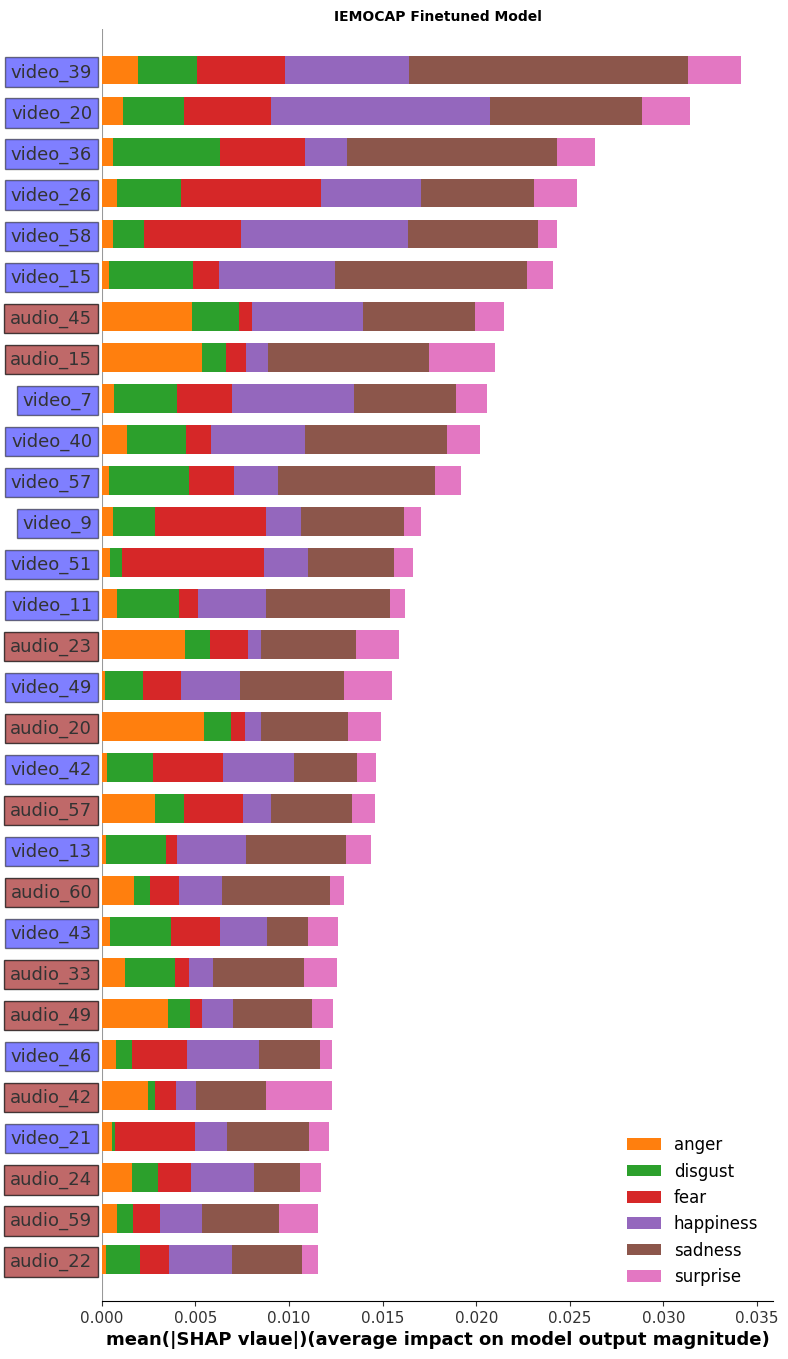

In [5]:
import matplotlib.pyplot as plt
import matplotlib
x_feature_names = ['text_' + str(i) for i in range(1024)] + ['video_' + str(i) for i in range(64)] + ['audio_' + str(i) for i in range(64)]
# x_feature_names = ['text', 'video', 'audio']

colors = matplotlib.colors.ListedColormap(plt.cm.tab10.colors[1:7])

shap.summary_plot(data['SHAP_value'], class_names=['anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise'],\
                  color=colors, feature_names=x_feature_names, show=False, class_inds='original', sort=True, max_display=30)
# shap.summary_plot(data['SHAP_value'], data['test_feature'], class_names=['anger', 'happiness', 'sadness', 'surprise'],\
#                   color=colors, feature_names=x_feature_names, show=False, class_inds='original', sort=True, max_display=30)
# labels = plt.gca().get_yticklabels()
yticklabels = plt.yticks()[1]
for label in yticklabels:
    if label.get_text()[:4] == 'text':
        label.set_bbox({'facecolor': 'red', 'alpha': 0.7})
    elif label.get_text()[:5] == 'video':
        label.set_bbox({'facecolor': 'blue', 'alpha': 0.5})
    elif label.get_text()[:5] == 'audio':
        label.set_bbox({'facecolor': 'brown', 'alpha': 0.7})
# print(labels)
plt.title('IEMOCAP Finetuned Model',fontsize=15,fontproperties="DejaVu Sans",weight='bold')
# plt.title('RAVDESS Base Model',fontsize=15,fontproperties="DejaVu Sans",weight='bold')
# plt.title('MELD Pretrained Model',fontsize=15,fontproperties="DejaVu Sans",weight='bold')
plt.xlabel('mean(|SHAP value|)(average impact on model output magnitude)',fontsize=13,fontproperties="DejaVu Sans",weight='bold')
# plt.savefig('/home/matt/Final_result/Class Imbalance/SHAP/SHAP_plot_1152/summary_plot.png', bbox_inches='tight')
# plt.savefig('/home/matt/Final_result/Origin_training/SHAP/SHAP_plot_1152/summary_plot.png', bbox_inches='tight')
# plt.savefig('/home/matt/Pictures/summary_plot.png', bbox_inches='tight')
plt.show()

In [6]:
for i in range(6):
    text = np.sum(np.abs(data['SHAP_value'][i][:, :1024]), axis=1)  # text
    video = np.sum(np.abs(data['SHAP_value'][i][:, 1024:1088]), axis=1)  # video
    audio = np.sum(np.abs(data['SHAP_value'][i][:, 1088:]), axis=1)  # audio
    # 將結果拼接成 (4112, 3)
    data['SHAP_value'][i] = np.stack((text, video, audio), axis=1)

In [7]:
# for i in range(6):
#     text = np.mean(np.abs(data['SHAP_value'][i][:, :1024]), axis=1)  # text
#     video = np.mean(np.abs(data['SHAP_value'][i][:, 1024:1088]), axis=1)  # video
#     audio = np.mean(np.abs(data['SHAP_value'][i][:, 1088:]), axis=1)  # audio
#     # 將結果拼接成 (4112, 3)
#     data['SHAP_value'][i] = np.stack((text, video, audio), axis=1)

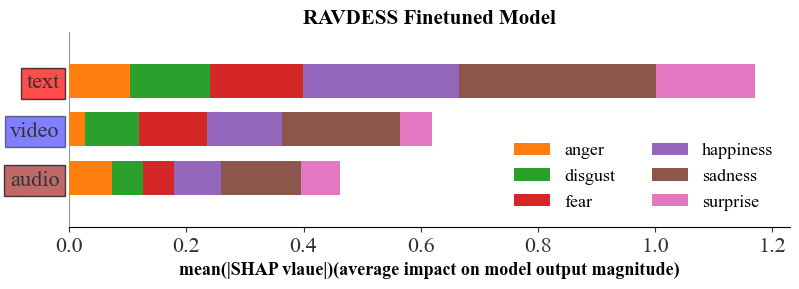

In [8]:
import matplotlib.pyplot as plt
import matplotlib

plt.rc('font',family='Times New Roman')
x_feature_names = ['text', 'video', 'audio']

colors = matplotlib.colors.ListedColormap(plt.cm.tab10.colors[1:7])

# shap.summary_plot(data['SHAP_value'], class_names=['anger', 'happiness', 'sadness', 'surprise'],\
#                   color=colors, feature_names=x_feature_names, show=False, class_inds='original', sort=True)
shap.summary_plot(data['SHAP_value'], class_names=['anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise'],\
                  color=colors, feature_names=x_feature_names, show=False, class_inds='original', sort=True)

# labels = plt.gca().get_yticklabels()
yticklabels = plt.yticks()[1]
for label in yticklabels:
    label.set_fontsize(16) 
    if label.get_text() == 'text':
        label.set_bbox({'facecolor': 'red', 'alpha': 0.7})
    elif label.get_text() == 'video':
        label.set_bbox({'facecolor': 'blue', 'alpha': 0.5})
    elif label.get_text() == 'audio':
        label.set_bbox({'facecolor': 'brown', 'alpha': 0.7})
plt.xticks(fontsize=16)
plt.legend(frameon=False, fontsize=13, ncol=2, loc='lower right')
# print(labels)
plt.title('RAVDESS Finetuned Model',fontsize=15,weight='bold')
# plt.title('RAVDESS Base Model',fontsize=15,fontproperties="DejaVu Sans",weight='bold')
# plt.title('IEMOCAP Pretrained Model(four class)',fontsize=15,weight='bold')
plt.xlabel('mean(|SHAP value|)(average impact on model output magnitude)',fontsize=13,weight='bold')
plt.savefig('/home/matt/Final_result/Origin_training/SHAP/SHAP_plot_3/summary_plot.png', bbox_inches='tight')
# plt.savefig('/home/matt/Pictures/summary_plot.png', bbox_inches='tight')
plt.show()